In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import heapq
import copy
from scipy.stats import mannwhitneyu, ttest_ind
from copy import deepcopy
from scipy.special import erfcinv

In [2]:
class Product:
    def __init__(self, name, initial_inventory, sell_prices, holding_cost, lead_time, s, S, demand_function):
        # Initial Parameters
        self.initial_inventory_amount = initial_inventory
        self.sell_prices_per_unit = sell_prices
        self.holding_cost_per_unit = holding_cost
        self.lead_time = lead_time
        self.demand_function = demand_function
        self.S = S
        self.s = s
        self.name = name
        
        self.reset_simulation_parameters()
        
    def reset_simulation_parameters(self):
        self.actual_inventory_amount = self.initial_inventory_amount
        
        self.total_inventory_holding_cost = 0
        self.total_order_amount = 0
        self.total_revenue = 0
        self.total_lost_amount = 0
    
    def charge_holding_cost(self, time):
        self.total_inventory_holding_cost += time * self.holding_cost_per_unit * self.actual_inventory_amount
    
    def get_revenue_and_losses(self, demand):
        w =  min(demand, self.actual_inventory_amount)
        self.total_revenue += w * self.sell_prices_per_unit
        self.total_lost_amount += (demand - w) * self.sell_prices_per_unit
        self.actual_inventory_amount -= w
       
    def summary(self):
        return {
        "product_name": self.name,
        "holding_cost": self.total_inventory_holding_cost,
        "order_amount": self.total_order_amount,
        "revenue": self.total_revenue,
        "lost_amount": self.total_lost_amount,
        "net_profit": self.total_revenue - self.total_inventory_holding_cost - self.total_order_amount
        }

In [49]:

class InventoryKStockSimulator:
    def __init__(self, customer_arrival_function, customer_demand_function, order_cost_function, 
                products: list["Product"], closing_time: int):
        
        # Parameters
        self.customer_arrival_function = customer_arrival_function
        self.customer_demand_function = customer_demand_function
        self.order_cost_function = order_cost_function
        self.products_list = products
        self.closing_time = closing_time
        
    
    def initialize_variables(self):
        # System State Variables
        for product in self.products_list:
            product.reset_simulation_parameters()
        
        # Events Variables
        self.time = 0
        self.events_queue = []
        self.actual_ordered_products = {i: False for i in range(len(self.products_list))}
        
    
    def process_customer(self, current_time):
        
        
        for product_id in self.customer_demand_function(len(self.products_list)):
            
            product = self.products_list[product_id]

            demand = product.demand_function()
            product.get_revenue_and_losses(demand)       
            
            if not self.actual_ordered_products[product_id] and product.actual_inventory_amount < product.s:
                amount = product.S - product.actual_inventory_amount
                new_time = current_time + product.lead_time
                heapq.heappush(self.events_queue, (new_time, 'order', product_id, amount))
                self.events_list.append({"event": "order", "time": new_time, "product_id": product_id, "amount": amount})
                self.actual_ordered_products[product_id] = True
            
        if self.time < self.closing_time:
            new_time = current_time + self.customer_arrival_function()
            heapq.heappush(self.events_queue, (new_time, 'customer'))
            self.events_list.append({"event": "customer", "time": new_time})
            
        self.time = current_time
    
            
    def process_order(self, current_time, product_id, amount):
        
        product = self.products_list[product_id]
                
        product.total_order_amount += self.order_cost_function(amount)
        product.actual_inventory_amount += amount
        
        
        if product.actual_inventory_amount < product.s:
            amount = product.S - product.actual_inventory_amount
            new_time = current_time + product.lead_time
            heapq.heappush(self.events_queue, (new_time, 'order', product_id, amount))
            self.events_list.append({"event": "order", "time": new_time, "product_id": product_id, "amount": amount})
        else:
            self.actual_ordered_products[product_id] = False
        
        
        self.time = current_time

    
    def simulations(self,num_sim: int) -> list[list[dict]]:
        results = []
        self.all_events_list = []
        for _ in range(num_sim):
            results.append(self.run())
            self.all_events_list.append(deepcopy(self.events_list))
        return results
    
    def run(self) -> list[dict]:
        
        self.initialize_variables()
        
        new_time = self.customer_arrival_function()
        heapq.heappush(self.events_queue, (new_time, 'customer'))
        self.events_list = [{"event": "customer", "time": new_time}]
        
        
        while self.events_queue:
            event = heapq.heappop(self.events_queue)
            
            for product in self.products_list:
                product.charge_holding_cost(event[0] - self.time)
            
            if event[1] == "customer":
                self.process_customer(event[0])
            else:
                self.process_order(event[0], event[2], event[3])

        return [product.summary() for product in self.products_list]

In [4]:
def customer_arrival_function(lamb = 1.0): 
    return np.random.exponential(lamb)

def customer_demand_function(max_length):
    if max_length <= 1:
        return [0]
    
    size = np.random.randint(low=1, high=max_length)
    return np.random.choice(max_length, size=size, replace=False)
         
def order_cost_function(y):
    return 5 + 2 * y 


¿Cual es la ganancia neta promedio de tres productos diferentes?

In [5]:
# Crear instancias de productos
products = [
    Product(
        name="Producto A (Alta rotación)",
        initial_inventory=30,
        sell_prices=15,
        holding_cost=0.3,
        lead_time=1,
        s=10,
        S=40,
        demand_function=lambda: np.random.poisson(8)
    ),
    Product(
        name="Producto B (Bajo costo)",
        initial_inventory=50,
        sell_prices=8,
        holding_cost=0.1,
        lead_time=3,
        s=15,
        S=60,
        demand_function=lambda: np.random.poisson(5)
    ),
    Product(
        name="Producto C (Lujo)",
        initial_inventory=10,
        sell_prices=50,
        holding_cost=1.2,
        lead_time=2,
        s=3,
        S=25,
        demand_function=lambda: np.random.poisson(2)
    )
]


# Configurar simulador
event_list = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function,
    products=products,
    closing_time=100
)


In [ ]:
def simulate_inventory(sim, n_sim=100):
    acceptable_d = 30
    n_sim = 100
    c = erfcinv(0.005)

    # Diccionario para guardar los datos por producto
    data_per_product_dm = {}

    while True:
        summaries_list = sim.simulations(n_sim)
        
        for summaries in summaries_list:
            for summary in summaries:
                name = summary["product_name"]
                if name not in data_per_product_dm:
                    data_per_product_dm[name] = {
                        "net_profit": [],
                        "holding_cost": [],
                        "order_amount": [],
                        "revenue": [],
                        "lost_amount": []
                    }
                for k in data_per_product_dm[name]:
                    data_per_product_dm[name][k].append(summary[k])
        
        converged = True
        for name, metrics in data_per_product_dm.items():
            std = np.std(metrics["net_profit"])  # Puedes cambiar por otra métrica si lo deseas
            n = len(metrics["net_profit"])
            margin = c * (std / np.sqrt(n))
            if margin > acceptable_d:
                converged = False
                break
        
        if converged:
            print(f"Estimate means have converged with {n} simulations:\n")
            for name, metrics in data_per_product_dm.items():
                print(f"--- {name} ---")
                for k in metrics:
                    print(f"{k}: {np.mean(metrics[k]):.2f}")
                print()
            break
        
        n_sim = 30

    return data_per_product_dm 

data_per_product_dm = simulate_inventory(event_list)

Estimate means have converged with 2680 simulations:

--- Producto A (Alta rotación) ---
net_profit: 4201.27
holding_cost: 725.52
order_amount: 815.37
revenue: 5742.16
lost_amount: 368.37

--- Producto B (Bajo costo) ---
net_profit: 1158.88
holding_cost: 328.82
order_amount: 498.20
revenue: 1985.90
lost_amount: 54.38

--- Producto C (Lujo) ---
net_profit: 2963.58
holding_cost: 1577.47
order_amount: 221.45
revenue: 4762.50
lost_amount: 320.32



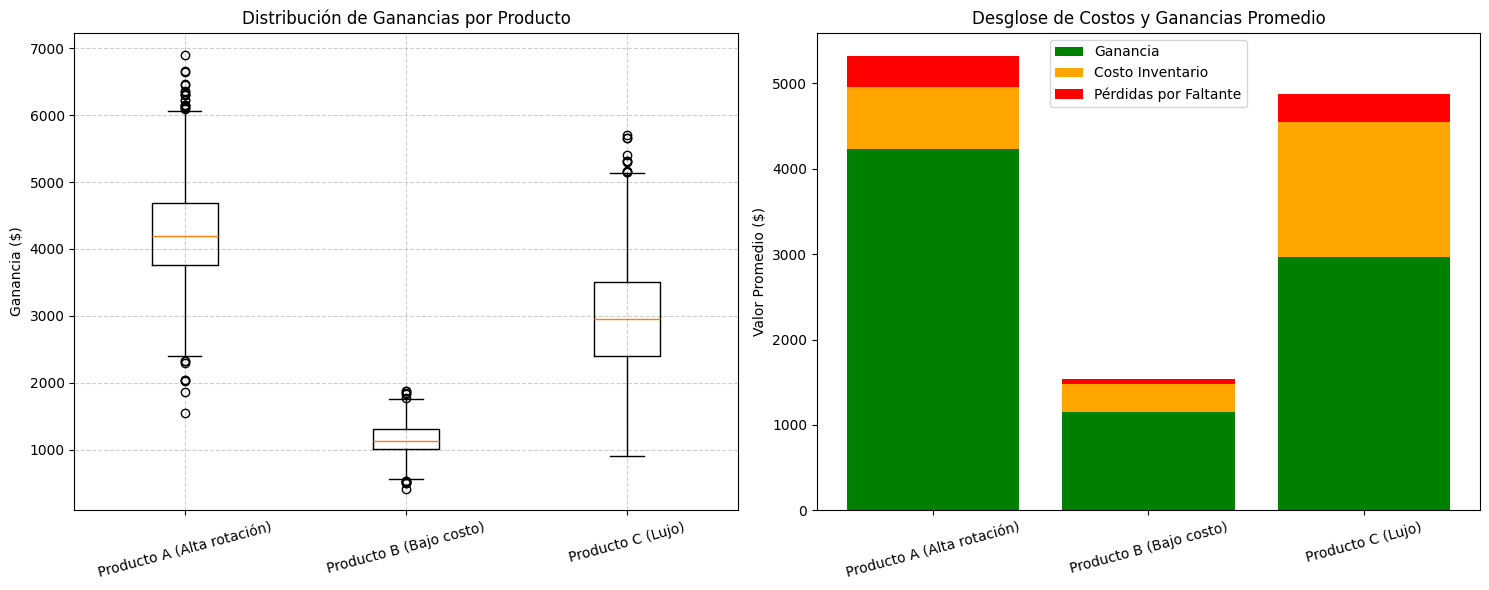

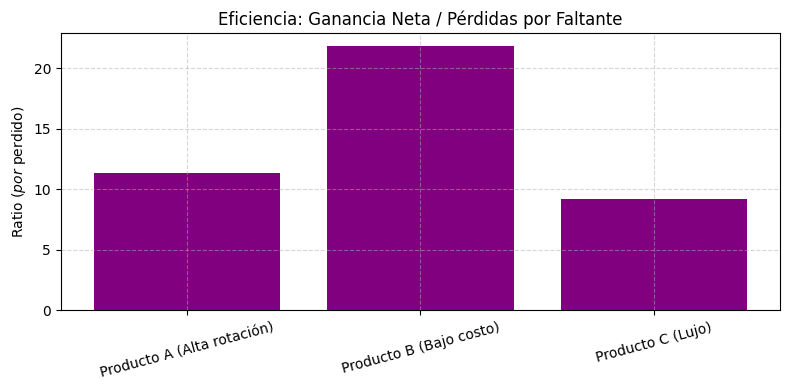

In [7]:
def analyze_data_per_product(data_per_product):
    product_names = list(data_per_product.keys())
    n_products = len(product_names)

    # --- Recuperar vectores ---
    profits_by_product = [data_per_product[name]['net_profit'] for name in product_names]
    holding_by_product = [data_per_product[name]['holding_cost'] for name in product_names]
    lost_by_product = [data_per_product[name]['lost_amount'] for name in product_names]

    # --- Subplots ---
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    
    # --- Gráfico de Caja: Ganancias ---
    axs[0].boxplot(profits_by_product, labels=product_names)
    axs[0].set_title('Distribución de Ganancias por Producto')
    axs[0].set_ylabel('Ganancia ($)')
    axs[0].grid(True, linestyle='--', alpha=0.6)
    axs[0].tick_params(axis='x', rotation=15)

    # --- Gráfico de Barras Apiladas: Costos, Ganancias, Pérdidas ---
    mean_gains = [np.mean(profits) for profits in profits_by_product]
    mean_holding = [np.mean(holding) for holding in holding_by_product]
    mean_lost = [np.mean(lost) for lost in lost_by_product]

    bottom = np.zeros(n_products)
    indices = np.arange(n_products)

    axs[1].bar(indices, mean_gains, label='Ganancia', color='green')
    axs[1].bar(indices, mean_holding, label='Costo Inventario', bottom=mean_gains, color='orange')
    axs[1].bar(indices, mean_lost, label='Pérdidas por Faltante', bottom=np.array(mean_gains)+np.array(mean_holding), color='red')

    axs[1].set_title('Desglose de Costos y Ganancias Promedio')
    axs[1].set_ylabel('Valor Promedio ($)')
    axs[1].set_xticks(indices)
    axs[1].set_xticklabels(product_names, rotation=15)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    # --- Gráfico de Barras: Ganancia por cada dólar perdido ---
    ratios = [
        np.mean(data_per_product[name]['net_profit']) / np.mean(data_per_product[name]['lost_amount'])
        if np.mean(data_per_product[name]['lost_amount']) > 0 else np.nan
        for name in product_names
    ]
    plt.figure(figsize=(8, 4))
    plt.bar(product_names, ratios, color='purple')
    plt.title('Eficiencia: Ganancia Neta / Pérdidas por Faltante')
    plt.ylabel('Ratio ($ por $ perdido)')
    plt.xticks(rotation=15)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

analyze_data_per_product(data_per_product_dm)

 ¿Qué producto es más afectado por cambios en la demanda?


--- Demand mean: 2 ---
Converged after 3430 simulations

--- Demand mean: 4 ---
Converged after 6940 simulations

--- Demand mean: 6 ---
Converged after 10840 simulations

--- Demand mean: 8 ---
Converged after 14620 simulations

--- Demand mean: 10 ---
Converged after 18040 simulations

--- Demand mean: 12 ---
Converged after 23260 simulations

--- Demand mean: 14 ---
Converged after 25150 simulations


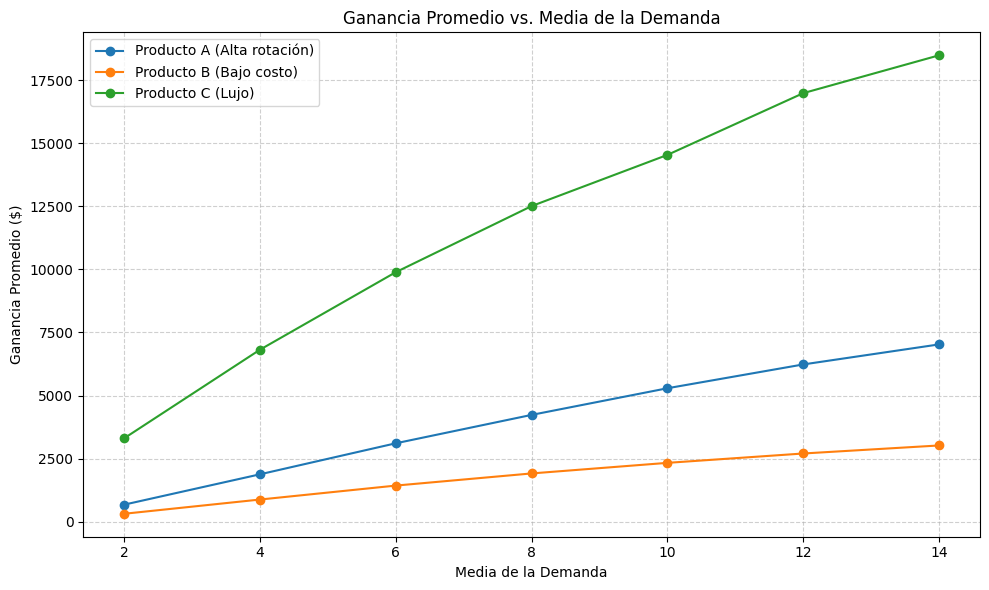

In [22]:
def demand_factory(mean, std=2):
    return lambda: max(0, np.random.normal(loc=mean, scale=std))

def estimate_profit_vs_demand(products, demand_means, acceptable_d=30, initial_sim=100):
    results = {p.name: [] for p in products}

    for mean in demand_means:
        print(f"\n--- Demand mean: {mean} ---")

        # Crear productos con la misma configuración excepto la nueva función de demanda
        updated_products = []
        for p in products:
            prod = deepcopy(p)
            prod.demand_function = demand_factory(mean)
            updated_products.append(prod)

        # Crear nueva instancia del simulador
        sim = InventoryKStockSimulator(
            customer_arrival_function=customer_arrival_function,
            customer_demand_function=customer_demand_function,
            order_cost_function=order_cost_function,
            products=updated_products,
            closing_time=100
        )
        
        # Simulación iterativa hasta convergencia
        c = erfcinv(0.005)
        data_per_product_dm = {p.name: [] for p in updated_products}
        n_sim = initial_sim

        while True:
            summaries_list = sim.simulations(n_sim)
    
            for summaries in summaries_list:
                for summary in summaries:
                    name = summary['product_name']
                    data_per_product_dm[name].append(summary['net_profit'])

            converged = True
            for name in data_per_product_dm:
                values = data_per_product_dm[name]
                std = np.std(values)
                margin = c * (std / np.sqrt(len(values)))
                if margin > acceptable_d:
                    converged = False
                    break

            if converged:
                print(f"Converged after {sum(len(v) for v in data_per_product_dm.values()) // len(products)} simulations")
                break
            n_sim = 30

        for name in results:
            mean_profit = np.mean(data_per_product_dm[name])
            results[name].append(mean_profit)

    return results

def plot_profit_vs_demand(results, demand_means):
    plt.figure(figsize=(10, 6))
    for name, profits in results.items():
        plt.plot(demand_means, profits, marker='o', label=name)
    plt.title('Ganancia Promedio vs. Media de la Demanda')
    plt.xlabel('Media de la Demanda')
    plt.ylabel('Ganancia Promedio ($)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

demand_means = [2, 4, 6, 8, 10, 12, 14]
results_price_sensitivity = estimate_profit_vs_demand(products, demand_means)
plot_profit_vs_demand(results_price_sensitivity, demand_means)


¿Qué pasa si cambian los precios de venta?

--- Sell prices multiplier 0.6 ---
Converged after 970 simulations 

--- Sell prices multiplier 0.8 ---
Converged after 1720 simulations 

--- Sell prices multiplier 1.0 ---
Converged after 2590 simulations 

--- Sell prices multiplier 1.2 ---
Converged after 3850 simulations 

--- Sell prices multiplier 1.4 ---
Converged after 5140 simulations 

--- Sell prices multiplier 1.6 ---
Converged after 6700 simulations 

--- Sell prices multiplier 1.8 ---
Converged after 8710 simulations 

--- Sell prices multiplier 2.0 ---
Converged after 10390 simulations 



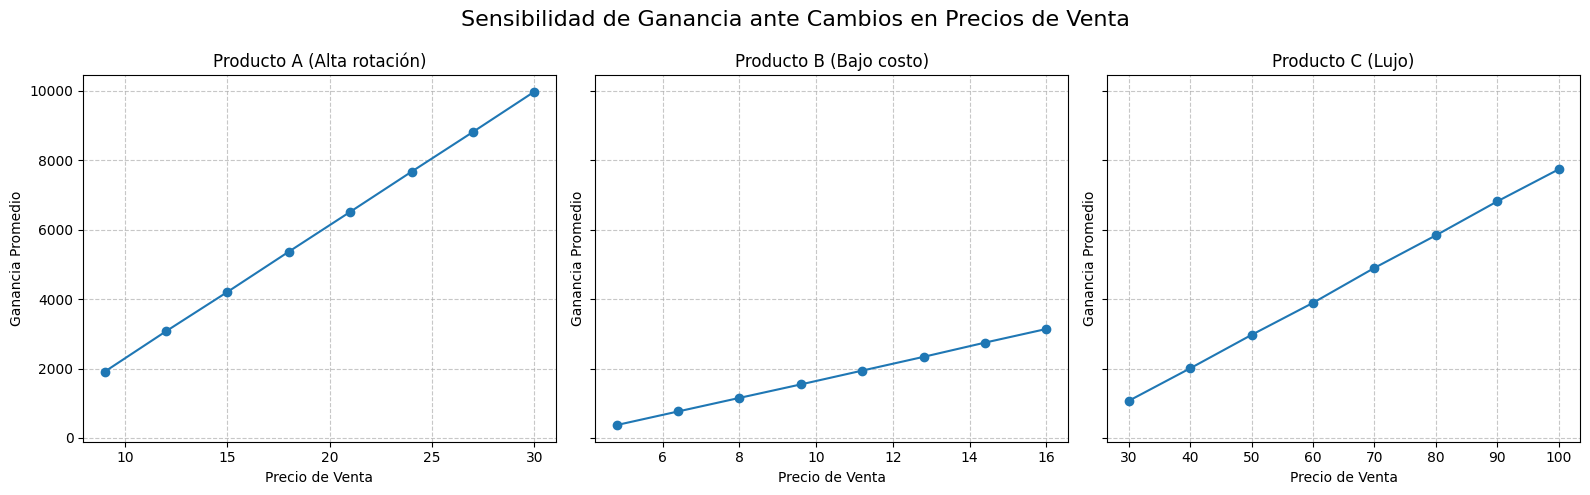

In [38]:
def simulate_price_sensitivity(products: list[Product], price_multipliers, acceptable_d=30, n_sim_init=100):

    confidence_z = erfcinv(0.005)
    results_per_product_sp = {p.name: {"prices": [], "profits": []} for p in products}

    for multiplier in price_multipliers:
        print(f"--- Sell prices multiplier {multiplier} ---")
        # Modificar precios
        updated_products = deepcopy(products)
        for p in updated_products:
            p.sell_prices_per_unit *= multiplier

        data_per_product_sp = {p.name: {"net_profit": []} for p in updated_products}
        n_sim = n_sim_init

        # Crear nueva instancia del simulador
        sim = InventoryKStockSimulator(
            customer_arrival_function=customer_arrival_function,
            customer_demand_function=customer_demand_function,
            order_cost_function=order_cost_function,
            products=updated_products,
            closing_time=100
        )
        
        while True:
            summaries_list = sim.simulations(n_sim)
    
            for summaries in summaries_list:
                for summary in summaries:
                    name = summary["product_name"]
                    data_per_product_sp[name]["net_profit"].append(summary["net_profit"])

            converged = True
            for name, data in data_per_product_sp.items():
                std = np.std(data["net_profit"])
                margin = confidence_z * std / np.sqrt(len(data["net_profit"]))
                if margin >= acceptable_d:
                    converged = False
                    break

            if converged:
                print(f"Converged after {len(data['net_profit'])} simulations \n")
                for name in results_per_product_sp:
                    results_per_product_sp[name]["prices"].append(
                        next(p.sell_prices_per_unit for p in updated_products if p.name == name)
                    )
                    results_per_product_sp[name]["profits"].append(np.mean(data_per_product_sp[name]["net_profit"]))
                break

            n_sim = 30  # agregar más simulaciones

    return results_per_product_sp

def plot_price_sensitivity(results_per_product_sp):
    fig, axs = plt.subplots(1, len(results_per_product_sp), figsize=(16, 5), sharey=True)
    fig.suptitle("Sensibilidad de Ganancia ante Cambios en Precios de Venta", fontsize=16)

    for ax, (product, data) in zip(axs, results_per_product_sp.items()):
        prices = data["prices"]
        profits = data["profits"]

        ax.plot(prices, profits, marker='o')
        ax.set_title(product)
        ax.set_xlabel("Precio de Venta")
        ax.set_ylabel("Ganancia Promedio")
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
price_multipliers = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]
results_price_sensitivity = simulate_price_sensitivity(products, price_multipliers=price_multipliers)
plot_price_sensitivity(results_price_sensitivity)



¿Cual producto es mas rentable?

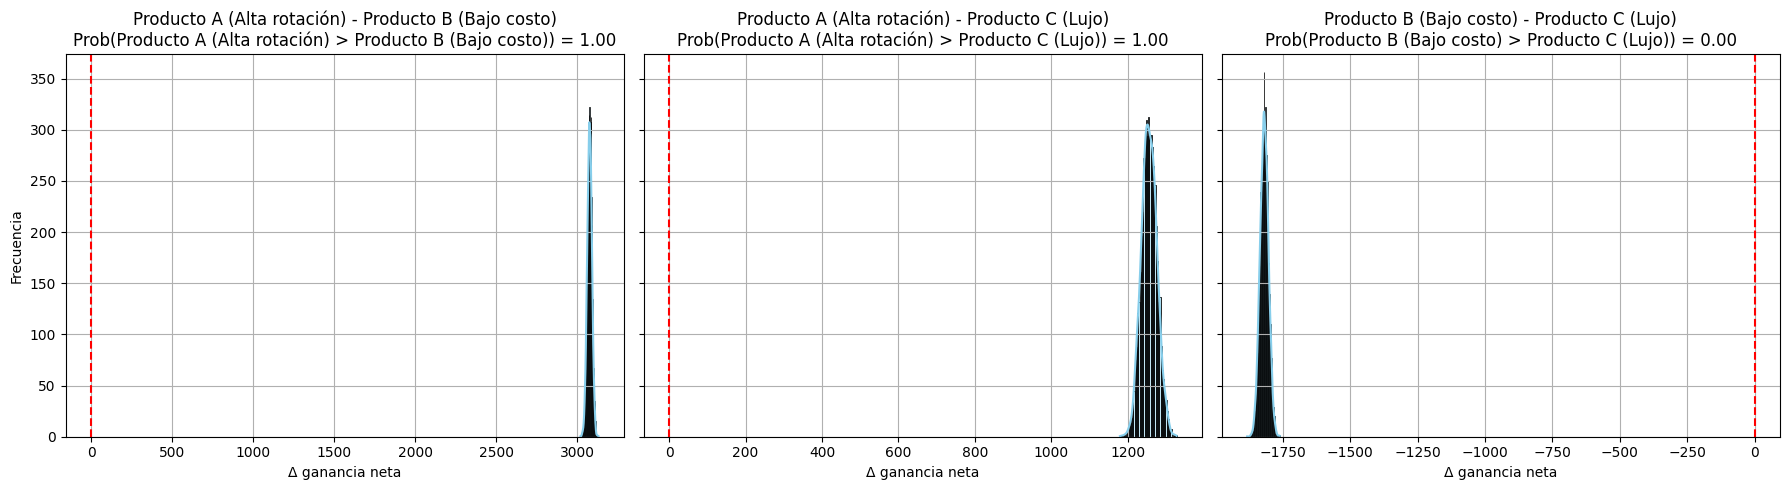

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns

def bootstrap_profit_comparison(data_per_product, n_bootstrap=5000, seed=42):
    np.random.seed(seed)
    product_names = list(data_per_product.keys())
    comparisons = list(combinations(product_names, 2))
    bootstrap_results = {}

    for p1, p2 in comparisons:
        profits_p1 = np.array(data_per_product[p1]["net_profit"])
        profits_p2 = np.array(data_per_product[p2]["net_profit"])

        diffs = []
        for _ in range(n_bootstrap):
            sample_p1 = np.random.choice(profits_p1, size=len(profits_p1), replace=True)
            sample_p2 = np.random.choice(profits_p2, size=len(profits_p2), replace=True)
            diffs.append(np.mean(sample_p1) - np.mean(sample_p2))

        diffs = np.array(diffs)
        prob_p1_greater = np.mean(diffs > 0)
        bootstrap_results[(p1, p2)] = {
            "diffs": diffs,
            "mean_diff": np.mean(diffs),
            "p({} > {})".format(p1, p2): prob_p1_greater
        }

    return bootstrap_results

def plot_bootstrap_results(bootstrap_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    for ax, ((p1, p2), result) in zip(axes, bootstrap_results.items()):
        diffs = result['diffs']
        prob = result[f'p({p1} > {p2})']
        sns.histplot(diffs, kde=True, color='skyblue', ax=ax)
        ax.axvline(0, color='red', linestyle='--')
        ax.set_title(f"{p1} - {p2}\nProb({p1} > {p2}) = {prob:.2f}")
        ax.set_xlabel("Δ ganancia neta")
        ax.grid(True)

    axes[0].set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()


bootstrap_results = bootstrap_profit_comparison(data_per_product_dm)
plot_bootstrap_results(bootstrap_results)

¿Qué tan riesgoso es cada producto?

Producto A (Alta rotación)
  STD promedio: 704.50
  CV promedio: 0.1666
Producto B (Bajo costo)
  STD promedio: 222.14
  CV promedio: 0.1925
Producto C (Lujo)
  STD promedio: 775.94
  CV promedio: 0.2610


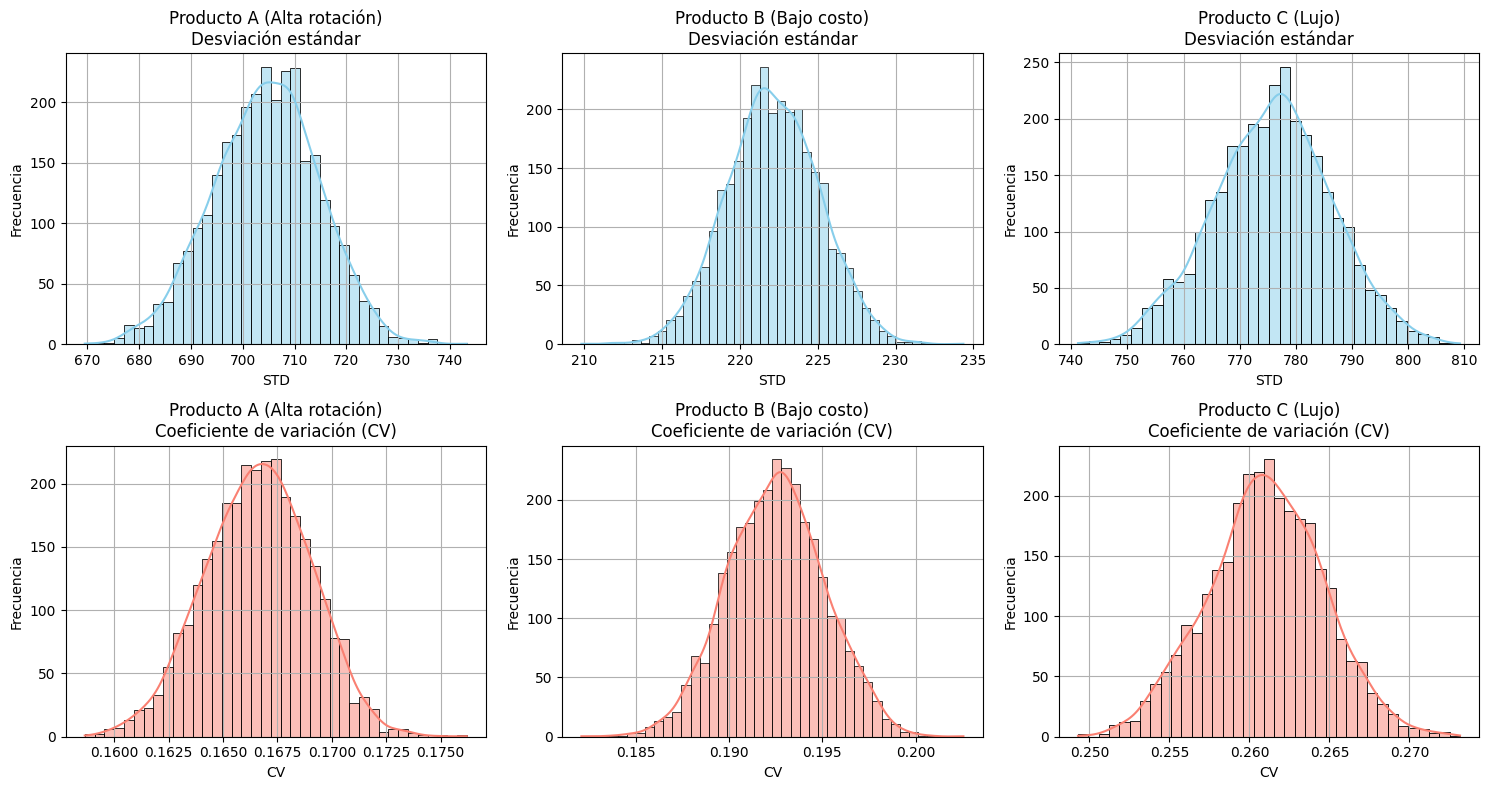

In [15]:
def bootstrap_risky_product(data_per_product_dm):
    rng = np.random.default_rng(seed=42)
    n_bootstrap = 3000
    bootstrap_results = {}

    for product in data_per_product_dm:
        profits = data_per_product_dm[product]["net_profit"]
        profits = np.array(profits)

        if profits.ndim != 1:
            raise ValueError(f"Las ganancias para {product} no son un vector 1D.")

        stds = []
        cvs = []
        for _ in range(n_bootstrap):
            sample = rng.choice(profits, size=profits.shape[0], replace=True)
            std = np.std(sample)
            mean = np.mean(sample)
            cv = std / mean if mean != 0 else np.nan
            stds.append(std)
            cvs.append(cv)

        bootstrap_results[product] = {
            "std_mean": np.mean(stds),
            "cv_mean": np.mean(cvs),
            "std_samples": stds,
            "cv_samples": cvs
        }

    # Mostrar resultados
    for product, stats in bootstrap_results.items():
        print(f"{product}")
        print(f"  STD promedio: {stats['std_mean']:.2f}")
        print(f"  CV promedio: {stats['cv_mean']:.4f}")

    return bootstrap_results

def plot_bootsrtap_risky(bootstrap_results):

    products = list(bootstrap_results.keys())

    fig, axes = plt.subplots(2, len(products), figsize=(5 * len(products), 8))

    for i, product in enumerate(products):
        # Histograma de desviaciones estándar
        sns.histplot(bootstrap_results[product]["std_samples"], kde=True, ax=axes[0, i], color='skyblue')
        axes[0, i].set_title(f"{product}\nDesviación estándar")
        axes[0, i].set_xlabel("STD")
        axes[0, i].set_ylabel("Frecuencia")
        axes[0, i].grid(True)

        # Histograma de coeficiente de variación
        sns.histplot(bootstrap_results[product]["cv_samples"], kde=True, ax=axes[1, i], color='salmon')
        axes[1, i].set_title(f"{product}\nCoeficiente de variación (CV)")
        axes[1, i].set_xlabel("CV")
        axes[1, i].set_ylabel("Frecuencia")
        axes[1, i].grid(True)

    plt.tight_layout()
    plt.show()


bootstrap_risky_results = bootstrap_risky_product(data_per_product_dm)
plot_bootsrtap_risky(bootstrap_risky_product)

Sobrestock y quiebre de stock

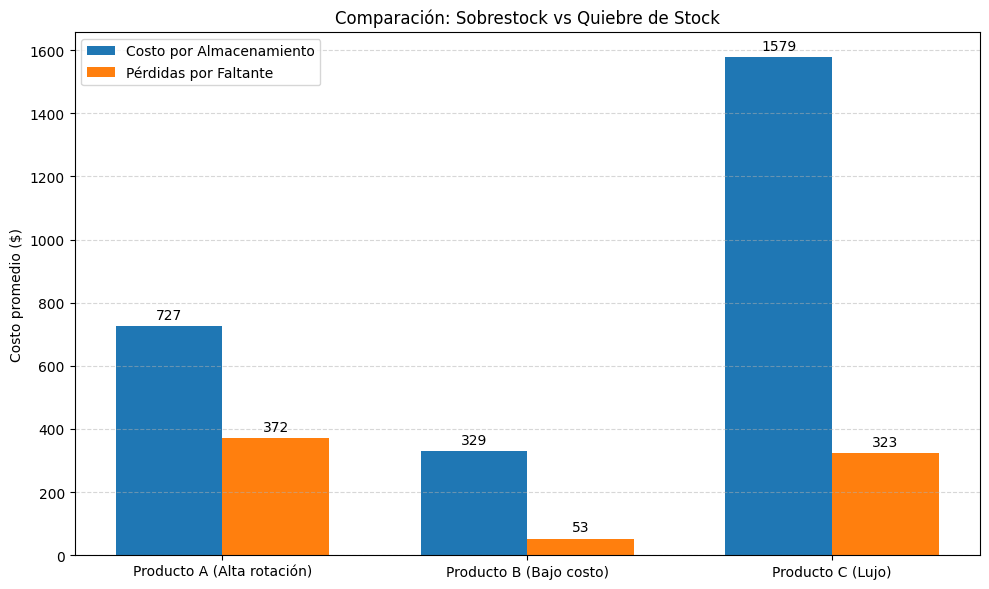

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_overstock_vs_stockout(data_per_product_dm):
    product_names = list(data_per_product_dm.keys())
    holding_means = [np.mean(data["holding_cost"]) for data in data_per_product_dm.values()]
    lost_means = [np.mean(data["lost_amount"]) for data in data_per_product_dm.values()]

    x = np.arange(len(product_names))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, holding_means, width, label='Costo por Almacenamiento')
    bars2 = ax.bar(x + width/2, lost_means, width, label='Pérdidas por Faltante')

    ax.set_ylabel('Costo promedio ($)')
    ax.set_title('Comparación: Sobrestock vs Quiebre de Stock')
    ax.set_xticks(x)
    ax.set_xticklabels(product_names)
    ax.legend()
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.0f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

analyze_overstock_vs_stockout(data_per_product_dm)

In [ ]:
# Crear dos configuraciones: s=10 (base) y s=15 (nueva)
product_c_s25 = deepcopy(products[0])
product_c_s25.s = 10
product_c_s25.name = "Producto A (s=10)"

product_c_s20 = deepcopy(products[0])
product_c_s20.s = 15
product_c_s20.name = "Producto A (s=15)"

# Simular
sim_S25_S20 = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function,
    products=[product_c_s25, product_c_s20],
    closing_time=100
)

result_a_s10_s15 = simulate_inventory(sim_S25_S20)

lost_s10 = result_a_s10_s15["Producto A (s=10)"]["lost_amount"]
lost_s15 = result_a_s10_s15["Producto A (s=15)"]["lost_amount"]

# Prueba de hipótesis (reducción de faltantes)
stat, p_value = mannwhitneyu(lost_s10, lost_s15, alternative='greater')
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Rechazamos H₀. s=15 reduce faltantes significativamente.")
else:
    print("No se puede rechazar H₀. s=15 no reduce faltantes significativamente.")

# Reducción promedio
reduccion = (np.mean(lost_s10) - np.mean(lost_s15)) / np.mean(lost_s10) * 100
print(f"Reducción de faltantes: {reduccion:.1f}%")


Estimate means have converged with 2350 simulations:

--- Producto A (s=10) ---
net_profit: 4215.03
holding_cost: 724.29
order_amount: 816.81
revenue: 5756.13
lost_amount: 363.11

--- Producto A (s=15) ---
net_profit: 4287.69
holding_cost: 782.48
order_amount: 854.86
revenue: 5925.03
lost_amount: 178.60

p-value: 1.6760907282006976e-204
Rechazamos H₀. s=15 reduce faltantes significativamente.
Reducción de faltantes: 50.8%


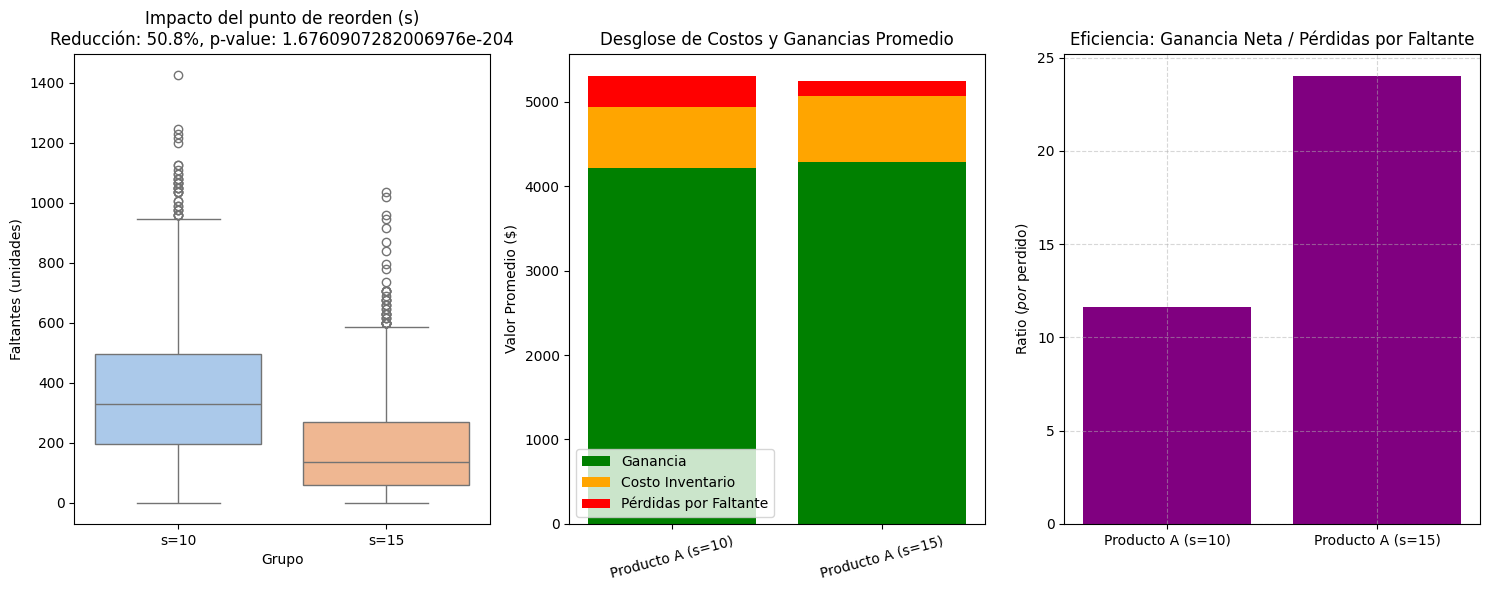

In [30]:
product_names = list(result_a_s10_s15.keys())
n_products = len(product_names)

# --- Recuperar vectores ---
profits_by_product = [result_a_s10_s15[name]['net_profit'] for name in product_names]
holding_by_product = [result_a_s10_s15[name]['holding_cost'] for name in product_names]
lost_by_product = [result_a_s10_s15[name]['lost_amount'] for name in product_names]

# --- Subplots ---
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# --- Gráfico de Caja ---
# Visualización
data = pd.DataFrame({
    'Faltantes': lost_s10 + lost_s15,
    'Grupo': ['Producto A (s=10)'] * len(lost_s10) + ['Producto A (s=15)'] * len(lost_s15)
})

sns.boxplot( data=data, x='Grupo', y='Faltantes',
    hue='Grupo',  # Opcional si quieres colores por grupo
    palette='pastel',
    ax=axs[0]     # Asignar al subplot
)

# Configuración de ejes y título (usando métodos de Matplotlib)
axs[0].set_ylabel('Faltantes (unidades)')
axs[0].set_title(f'Impacto del punto de reorden (s)\nReducción: {reduccion:.1f}%, p-value: {p_value}')

# --- Gráfico de Barras Apiladas: Costos, Ganancias, Pérdidas ---
mean_gains = [np.mean(profits) for profits in profits_by_product]
mean_holding = [np.mean(holding) for holding in holding_by_product]
mean_lost = [np.mean(lost) for lost in lost_by_product]

indices = np.arange(n_products)

axs[1].bar(indices, mean_gains, label='Ganancia', color='green')
axs[1].bar(indices, mean_holding, label='Costo Inventario', bottom=mean_gains, color='orange')
axs[1].bar(indices, mean_lost, label='Pérdidas por Faltante', bottom=np.array(mean_gains)+np.array(mean_holding), color='red')

axs[1].set_title('Desglose de Costos y Ganancias Promedio')
axs[1].set_ylabel('Valor Promedio ($)')
axs[1].set_xticks(indices)
axs[1].set_xticklabels(product_names, rotation=15)
axs[1].legend()

# --- Gráfico de Barras: Ganancia por cada dólar perdido ---
ratios = [
    np.mean(result_a_s10_s15[name]['net_profit']) / np.mean(result_a_s10_s15[name]['lost_amount'])
    if np.mean(result_a_s10_s15[name]['lost_amount']) > 0 else np.nan
    for name in product_names
]
axs[2].bar(product_names, ratios, color='purple')
axs[2].set_title('Eficiencia: Ganancia Neta / Pérdidas por Faltante')
axs[2].set_ylabel('Ratio ($ por $ perdido)')
axs[2].set_xticks(indices)
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
    

In [48]:
# Crear dos configuraciones: S=25 (base) y S=10 (nueva)
product_c_s25 = deepcopy(products[2])
product_c_s25.S = 25
product_c_s25.name = "Producto C (S=25)"

product_c_s20 = deepcopy(products[2])
product_c_s20.S = 20
product_c_s20.name = "Producto C (S=20)"

# Simular
sim_S25_S20 = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function,
    products=[product_c_s25, product_c_s20],
    closing_time=100
)

result_c_s25_s20 = simulate_inventory(sim_S25_S20)

holding_S25 = result_c_s25_s20["Producto C (S=25)"]["holding_cost"]
holding_S20 = result_c_s25_s20["Producto C (S=20)"]["holding_cost"]

# Prueba de hipótesis (reducción de faltantes)
stat, p_value = mannwhitneyu(holding_S25, holding_S20, alternative='greater')
print(f"p-value: {p_value}")
if p_value < 0.05:
    print("Rechazamos H₀. Los costos son menores con `S=20`.")
else:
    print("No se puede rechazar H₀. No hay diferencia en costos entre `S=25` y `S=20`.")

# Reducción promedio
reduccion = (np.mean(holding_S25) - np.mean(holding_S20)) / np.mean(holding_S25) * 100
print(f"Reducción de costo de almacenamiento: {reduccion:.1f}%")


Estimate means have converged with 2620 simulations:

--- Producto C (S=25) ---
net_profit: 2954.82
holding_cost: 1576.62
order_amount: 221.06
revenue: 4752.50
lost_amount: 320.40

--- Producto C (S=20) ---
net_profit: 3206.43
holding_cost: 1278.38
order_amount: 218.71
revenue: 4703.51
lost_amount: 392.23

p-value: 0.0
Rechazamos H₀. Los costos son menores con `S=20`.
Reducción de costo de almacenamiento: 18.9%


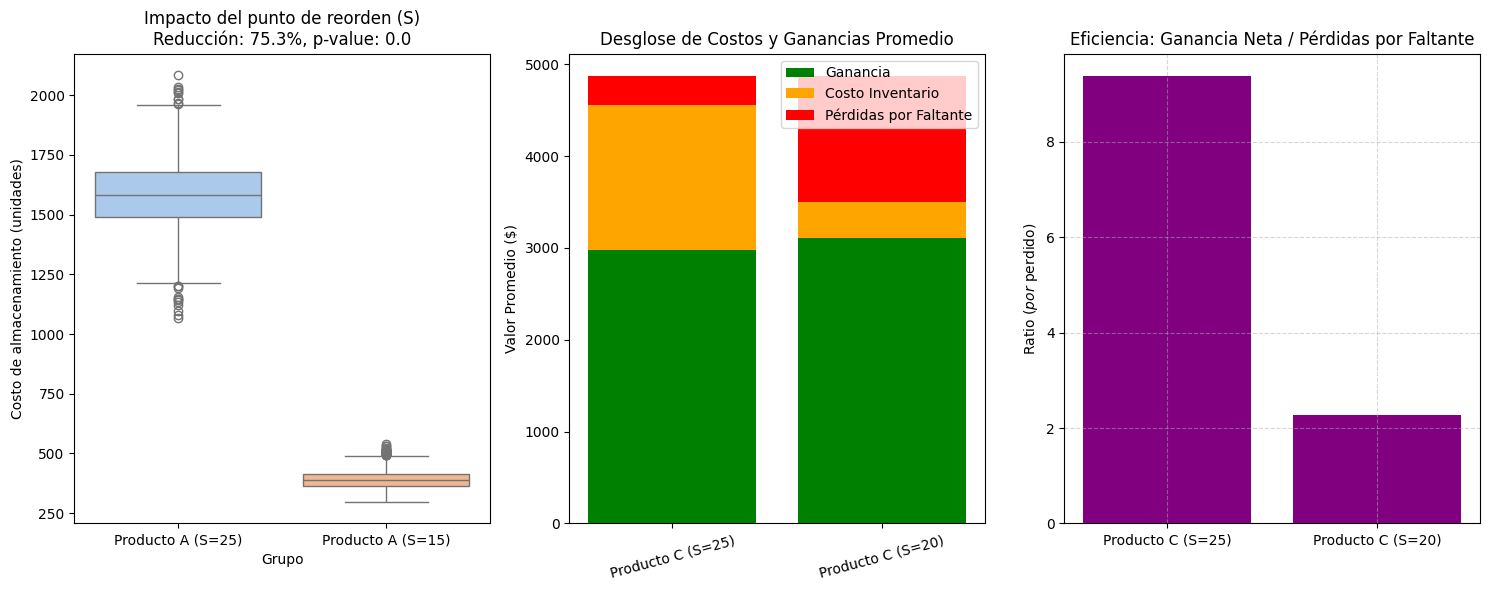

In [46]:
product_names = list(result_c_s25_s20.keys())
n_products = len(product_names)

# --- Recuperar vectores ---
profits_by_product = [result_c_s25_s20[name]['net_profit'] for name in product_names]
holding_by_product = [result_c_s25_s20[name]['holding_cost'] for name in product_names]
lost_by_product = [result_c_s25_s20[name]['lost_amount'] for name in product_names]

# --- Subplots ---
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# --- Gráfico de Caja ---
# Visualización
data = pd.DataFrame({
    'Costo de almacenamiento': holding_S25 + holding_S20,
    'Grupo': ['Producto A (S=25)'] * len(holding_S25) + ['Producto A (S=20)'] * len(holding_S20)
})

sns.boxplot( data=data, x='Grupo', y='Costo de almacenamiento',
    hue='Grupo',  # Opcional si quieres colores por grupo
    palette='pastel',
    ax=axs[0]     # Asignar al subplot
)

# Configuración de ejes y título (usando métodos de Matplotlib)
axs[0].set_ylabel('Costo de almacenamiento (unidades)')
axs[0].set_title(f'Impacto del punto de reorden (S)\nReducción: {reduccion:.1f}%, p-value: {p_value}')

# --- Gráfico de Barras Apiladas: Costos, Ganancias, Pérdidas ---
mean_gains = [np.mean(profits) for profits in profits_by_product]
mean_holding = [np.mean(holding) for holding in holding_by_product]
mean_lost = [np.mean(lost) for lost in lost_by_product]

indices = np.arange(n_products)

axs[1].bar(indices, mean_gains, label='Ganancia', color='green')
axs[1].bar(indices, mean_holding, label='Costo Inventario', bottom=mean_gains, color='orange')
axs[1].bar(indices, mean_lost, label='Pérdidas por Faltante', bottom=np.array(mean_gains)+np.array(mean_holding), color='red')

axs[1].set_title('Desglose de Costos y Ganancias Promedio')
axs[1].set_ylabel('Valor Promedio ($)')
axs[1].set_xticks(indices)
axs[1].set_xticklabels(product_names, rotation=15)
axs[1].legend()

# --- Gráfico de Barras: Ganancia por cada dólar perdido ---
ratios = [
    np.mean(result_c_s25_s20[name]['net_profit']) / np.mean(result_c_s25_s20[name]['lost_amount'])
    if np.mean(result_c_s25_s20[name]['lost_amount']) > 0 else np.nan
    for name in product_names
]
axs[2].bar(product_names, ratios, color='purple')
axs[2].set_title('Eficiencia: Ganancia Neta / Pérdidas por Faltante')
axs[2].set_ylabel('Ratio ($ por $ perdido)')
axs[2].set_xticks(indices)
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Total tiempos entre clientes: 50452
Lambda estimado: 0.9999
KS Test: D = 0.0038, p-value = 0.4715
No se rechaza H₀: los tiempos entre clientes siguen una distribución exponencial.


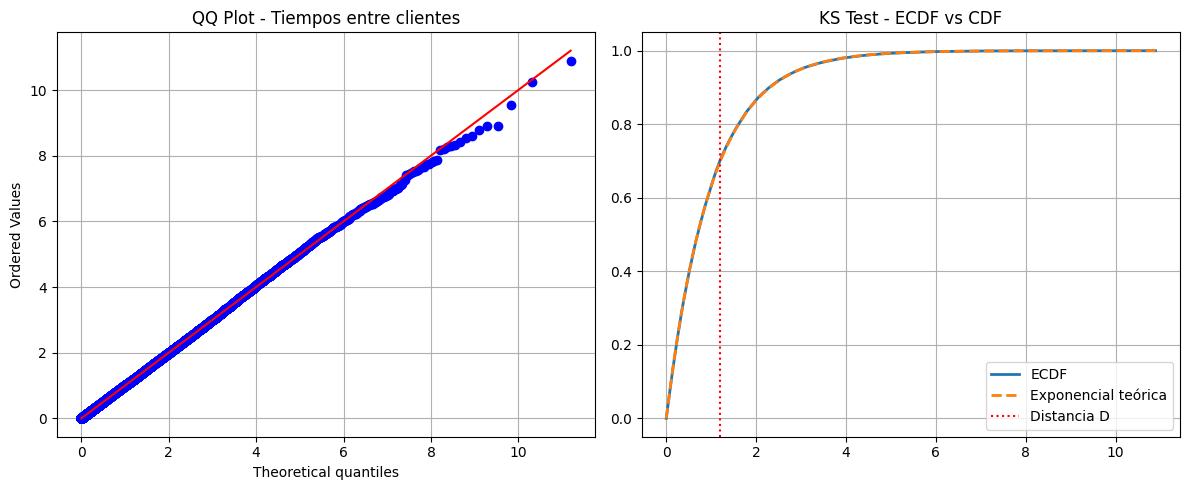

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot, kstest

# --- Recolectar tiempos entre clientes ---
sim_2 = InventoryKStockSimulator(
    customer_arrival_function=customer_arrival_function,
    customer_demand_function=customer_demand_function,
    order_cost_function=order_cost_function,
    products=products,
    closing_time=100
)

sim_2.simulations(500)

inter_arrival_times = []
for event_list in sim_2.all_events_list:
    customer_times = sorted(event['time'] for event in event_list if event['event'] == 'customer')
    if len(customer_times) >= 2:
        inter_arrival_times += list(np.diff(customer_times))

inter_arrival_times = np.array(inter_arrival_times)

# --- Estimar lambda ---
lambda_hat = 1 / np.mean(inter_arrival_times)
print(f"Total tiempos entre clientes: {len(inter_arrival_times)}")
print(f"Lambda estimado: {lambda_hat:.4f}")

# --- KS Test ---
D, p_value = kstest(inter_arrival_times, 'expon', args=(0, 1 / lambda_hat))
print(f"KS Test: D = {D:.4f}, p-value = {p_value:.4f}")
if p_value > 0.05:
    print("No se rechaza H₀: los tiempos entre clientes siguen una distribución exponencial.")
else:
    print("Se rechaza H₀: los tiempos entre clientes no siguen una distribución exponencial.")

# --- Graficar: QQ Plot + ECDF vs CDF ---
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import expon

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- QQ Plot ---
probplot(inter_arrival_times, dist="expon", sparams=(0, 1 / lambda_hat), plot=axs[0])
axs[0].set_title("QQ Plot - Tiempos entre clientes")
axs[0].grid(True)

# --- ECDF vs CDF ---
ecdf = ECDF(inter_arrival_times)
x_vals = np.linspace(0, np.max(inter_arrival_times), 1000)
cdf_vals = expon.cdf(x_vals, scale=1 / lambda_hat)

axs[1].plot(x_vals, ecdf(x_vals), label="ECDF", lw=2)
axs[1].plot(x_vals, cdf_vals, label="Exponencial teórica", lw=2, linestyle="--")
axs[1].axvline(x_vals[np.argmax(np.abs(ecdf(x_vals) - cdf_vals))], color='red', linestyle=':', label="Distancia D")
axs[1].set_title("KS Test - ECDF vs CDF")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()
